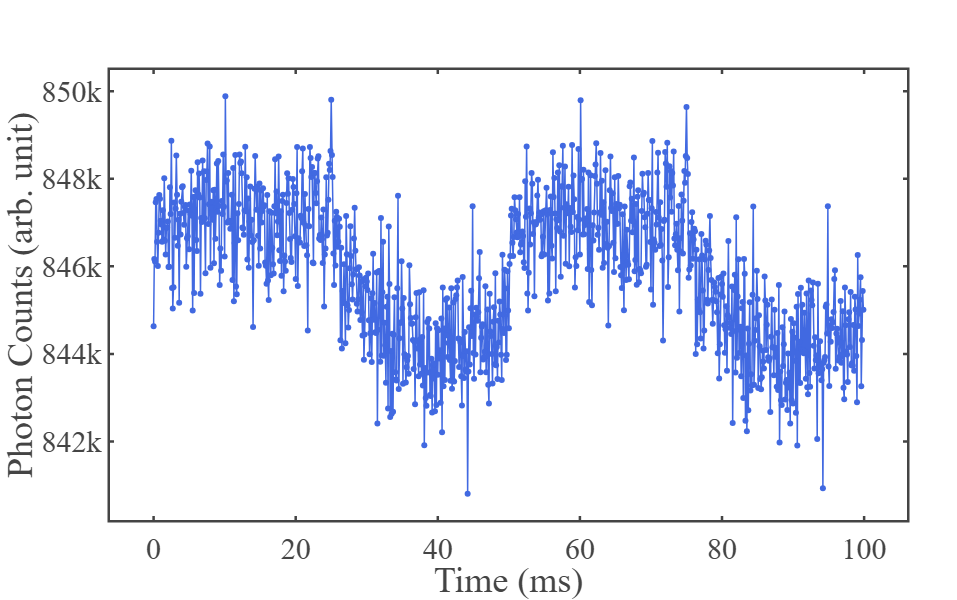

✅ Figure saved as: D:\Atanu\Atanu_Github\NaBiF4_PL_analysis\NaBiF4_PL_analysis\figures in paper\NaYF4_quenching.png


In [3]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.optimize import curve_fit
import plotly.io as pio
import os
import re

# --- Custom Plotly Template with axis label & tick label font sizes ---
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.5,
        'tickwidth': 2.5,
        'ticklen': 4,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
        # 'titlefont': dict(size=34),   # axis label font size
        # 'tickfont': dict(size=30),   # tick labels font size
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.5,
        'tickwidth': 2.5,
        'ticklen': 4,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
        # 'titlefont': dict(size=34),   # axis label font size
        # 'tickfont': dict(size=30),    # tick labels font size
    },
    'font': {
        'family': 'mathjax',
        'size': 30,  # legend, annotation, general text
    }
}

# ============================================================
# --- File Path ---
# ============================================================
file_path = r"D:\Atanu\Atanu_Github\NaBiF4_PL_analysis\NaBiF4_PL_analysis\datas\Aug\23 august\clean Particle\NaYF4\975nm_300mW_constant_1064nm_20Hz_pulsing.txt"

# ============================================================
# --- Load Data ---
# ============================================================
arr = np.loadtxt(file_path, skiprows=1)

time = arr[:, 0]
counts = arr[:, 1]

# ============================================================
# --- Plot Raw Data (hide legend) ---
# ============================================================
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=time / 1e9,          # convert to ms
    y=counts,
    mode='lines+markers',
    showlegend=False,
    line=dict(width=1.5, color='royalblue'),
))

# ============================================================
# --- Add Corrected Double Exponential Fit Curve (no normalization) ---
# ============================================================

# Fit parameters and constants (example values)
y0 = 4.9415e+5
A1 = 4485.3
tau1 = 7.5842e+8
A2 = 5729.9
tau2 = 7.4681e+9
X0 = 2.47e+10

# Fit x-range in ms
x1_ms, x2_ms = 24.7, 50
x_fit_orig = np.linspace(x1_ms, x2_ms, 400) * 1e9

y_fit = (
    y0
    + A1 * np.exp(-(x_fit_orig - X0) / tau1)
    + A2 * np.exp(-(x_fit_orig - X0) / tau2)
)

# # plot fit (convert x back to ms for plotting)
# fig.add_trace(go.Scatter(
#     x=x_fit_orig / 1e9,
#     y=y_fit,
#     mode='lines',
#     line=dict(width=3, color='crimson'),
#     showlegend=False
# ))

# ============================================================
# --- Figure Layout ---
# ============================================================
fig.update_layout(
    template=fig_template,
    xaxis_title="Time (ms)",
    yaxis_title="Photon Counts (arb. unit)",
    width=800,
    height=600,
    margin=dict(l=110, r=50, t=70, b=80),
)

# set explicit y-axis range if needed
# fig.update_yaxes(range=[492500, 506100])

# Optional: adjust x-axis range
# fig.update_xaxes(range=[0, 100])

fig.show()


# ============================================================
# --- Save Figure ---
# ============================================================
save_folder = r"D:\Atanu\Atanu_Github\NaBiF4_PL_analysis\NaBiF4_PL_analysis\figures in paper"
os.makedirs(save_folder, exist_ok=True)
output_path = os.path.join(save_folder, "NaYF4_quenching.png")
pio.write_image(fig, output_path, format='png', scale=4)
print(f"✅ Figure saved as: {output_path}")